## Generative Adversarial Network for Anime Face Generation

**Objective:**
In this assignment, you will implement Generative Adversarial Networks (GANs) to generate anime faces. Your goal is to explore different GAN architectures and demonstrate their ability to produce realistic-looking anime characters.

**Baselines:**
You are provided with several baselines, ranging in complexity and expected effort. Please aim to complete at least the first three baselines (Simple, Medium, Strong). The "Boss" level is optional but highly encouraged for those seeking an extra challenge.

*   **Simple (Random Submission)**
    *   **Description:** This baseline serves as a basic check. You can submit a notebook that generates random noise or trivial images.
*   **Medium (DCGAN + WGAN)**
    *   **Description:** Implement a Deep Convolutional GAN (DCGAN) with the Wasserstein GAN (WGAN) objective.
    *   **Estimated Time:** 2-6 hours
*   **Strong (DCGAN + SNGAN)**
    *   **Description:** Implement a Deep Convolutional GAN (DCGAN) enhanced with Spectral Normalization GAN (SNGAN).
    *   **Estimated Time:** 2-6 hours
*   **Boss (Advanced GANs)**
    *   **Description:** Explore and implement more advanced GAN architectures such as AutoGAN, BigGAN, Progressive GAN, Self-Attention GAN, or StyleGAN/StyleGAN2.
    *   **Estimated Time:** 6-16 hours
    *   **Note:** This baseline is optional.

**Evaluation:**
Your generated anime faces will be primarily evaluated through visual inspection. We will assess the quality and realism of the images produced in the "Generate and show some images" section of your notebooks. Strict quantitative GAN evaluation metrics are *not* required for this assignment.

**Submission:**
For each completed baseline, please submit a separate Colab notebook (`.ipynb` file). **Do not submit any additional generated image files**; all evaluation will be performed directly from the images displayed within your submitted notebooks.

## Set up the environment


### Packages Installation

In [1]:
# You may replace the workspace directory if you want.
workspace_dir = '/kaggle/input/datasets/ziggykor/anime-face-dataset-expanded-2024'

# Training progress bar
!pip install -q qqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.7 MB/s eta 0:00:00


### Dataset path (Kaggle)


In [2]:
import os

# Kaggle dataset path (Add Data -> ziggykor/anime-face-dataset-expanded-2024)
path = '/kaggle/input/datasets/ziggykor/anime-face-dataset-expanded-2024'
faces_dir = os.path.join(path, 'faces')

print('Dataset root:', path)
print('Faces folder:', faces_dir)
print('Number of images:', len(os.listdir(faces_dir)) if os.path.isdir(faces_dir) else 'faces/ not found')


100%|██████████| 630M/630M [00:05<00:00, 127MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ziggykor/anime-face-dataset-expanded-2024/versions/1


### Folder architecture of downloaded file.
```
faces/
├── 1.jpg
├── 2.jpg
├── 3.jpg
...
```

In [7]:
!ls -F "{faces_dir}" | head


流式输出内容被截断，只能显示最后 5000 行内容。
112862.jpg  130222.jpg	2605.jpg    43420.jpg  60782.jpg  78143.jpg  95504.jpg
112863.jpg  130223.jpg	26060.jpg   43421.jpg  60783.jpg  78144.jpg  95505.jpg
112864.jpg  130224.jpg	26061.jpg   43422.jpg  60784.jpg  78145.jpg  95506.jpg
112865.jpg  130225.jpg	26062.jpg   43423.jpg  60785.jpg  78146.jpg  95507.jpg
112866.jpg  130226.jpg	26063.jpg   43424.jpg  60786.jpg  78147.jpg  95508.jpg
112867.jpg  130227.jpg	26064.jpg   43425.jpg  60787.jpg  78148.jpg  95509.jpg
112868.jpg  130228.jpg	26065.jpg   43426.jpg  60788.jpg  78149.jpg  9550.jpg
112869.jpg  130229.jpg	26066.jpg   43427.jpg  60789.jpg  7814.jpg   95510.jpg
11286.jpg   13022.jpg	26067.jpg   43428.jpg  6078.jpg   78150.jpg  95511.jpg
112870.jpg  130230.jpg	26068.jpg   43429.jpg  60790.jpg  78151.jpg  95512.jpg
112871.jpg  130231.jpg	26069.jpg   4342.jpg   60791.jpg  78152.jpg  95513.jpg
112872.jpg  130232.jpg	2606.jpg    43430.jpg  60792.jpg  78153.jpg  95514.jpg
112873.jpg  130233.jpg	26070.jpg   4343

The image files are read directly from `faces_dir` below (no copy to workspace).


In [9]:
# faces_dir is set in the previous cell; used by get_dataset() later.
assert os.path.isdir(faces_dir), f'faces folder not found: {faces_dir}'


Moved '/root/.cache/kagglehub/datasets/ziggykor/anime-face-dataset-expanded-2024/versions/1/faces' to './faces'


## Random seed
Set the random seed to a certain value for reproducibility.

In [10]:
import random

import torch
import numpy as np


def same_seeds(seed):
    # Python built-in random module
    random.seed(seed)
    # Numpy
    np.random.seed(seed)
    # Torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

same_seeds(2021)

## Import Packages
First, we need to import packages that will be used later.
We highly rely on **torchvision**, a library of PyTorch.

In [11]:
import os
import glob

import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch import optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from qqdm.notebook import qqdm

## Dataset
1. Resize the images to (64, 64)
1. Linearly map the values from [0, 1] to  [-1, 1].

Please refer to [PyTorch official website](https://pytorch.org/vision/stable/transforms.html) for details about different transforms.


In [12]:
class CrypkoDataset(Dataset):
    def __init__(self, fnames, transform):
        self.transform = transform
        self.fnames = fnames
        self.num_samples = len(self.fnames)

    def __getitem__(self,idx):
        fname = self.fnames[idx]
        # 1. Load the image
        img = torchvision.io.read_image(fname)
        # 2. Resize and normalize the images using torchvision.
        img = self.transform(img)
        return img

    def __len__(self):
        return self.num_samples


def get_dataset(root):
    fnames = glob.glob(os.path.join(root, '*'))
    # 1. Resize the image to (64, 64)
    # 2. Linearly map [0, 1] to [-1, 1]
    compose = [
        transforms.ToPILImage(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ]
    transform = transforms.Compose(compose)
    dataset = CrypkoDataset(fnames, transform)
    return dataset

### Show some images
Note that the values are in the range of [-1, 1], we should shift them to the valid range, [0, 1], to display correctly.

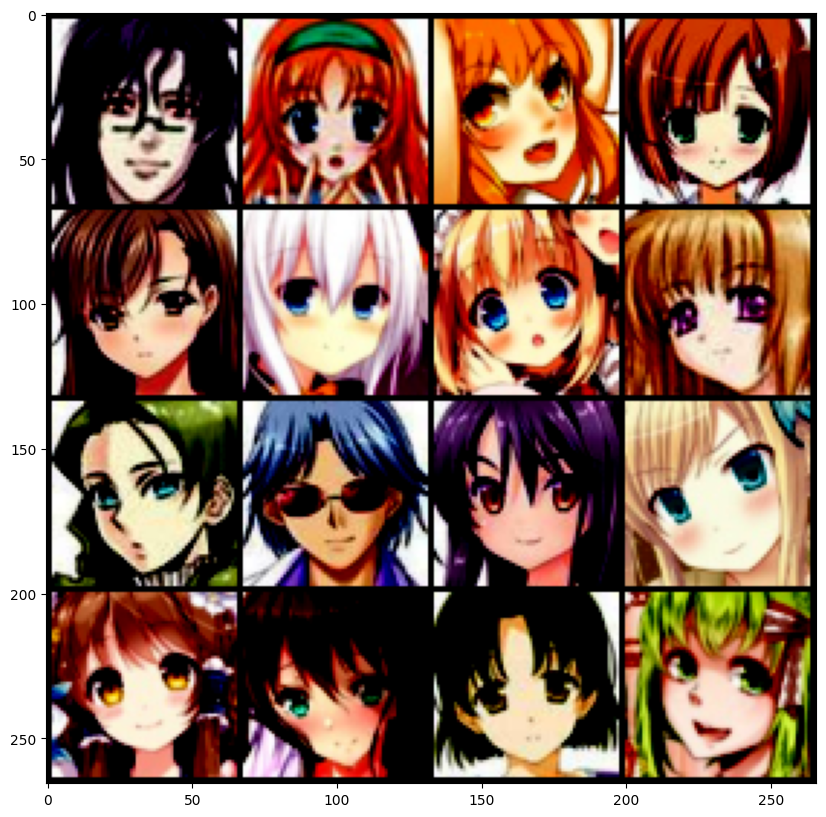

In [13]:
dataset = get_dataset(faces_dir)

images = [dataset[i] for i in range(16)]
grid_img = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(10,10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.show()

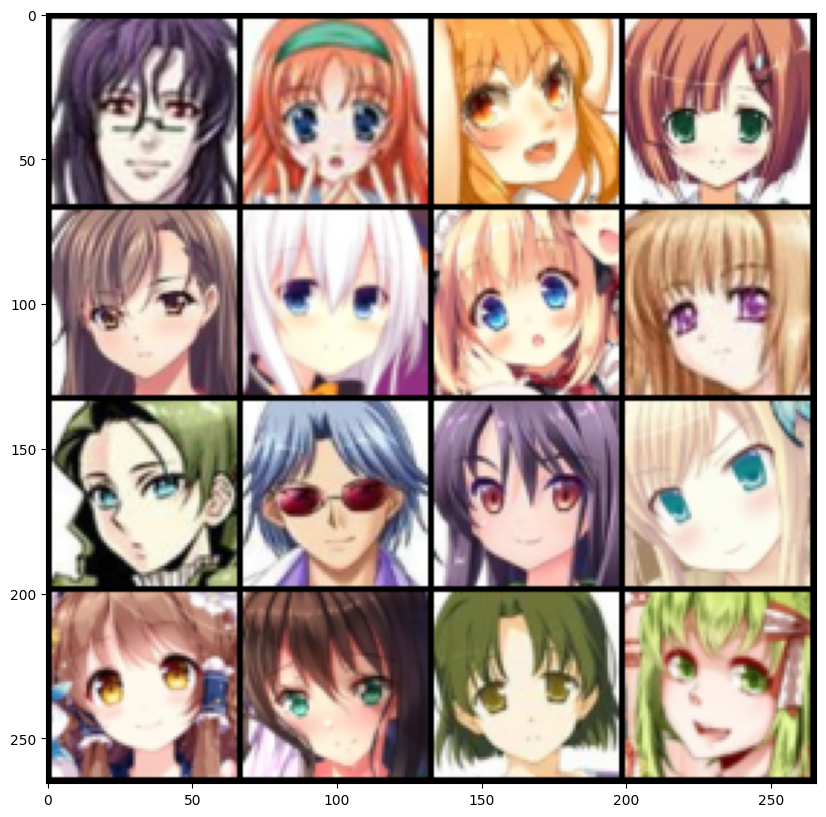

In [14]:
images = [(dataset[i]+1)/2 for i in range(16)]
grid_img = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(10,10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.show()

## Model
Here, we use DCGAN as the model structure. Feel free to modify your own model structure.

Note that the `N` of the input/output shape stands for the batch size.

In [15]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

class Generator(nn.Module):
    """
    Input shape: (N, in_dim)
    Output shape: (N, 3, 64, 64)
    """
    def __init__(self, in_dim, dim=64):
        super(Generator, self).__init__()
        def dconv_bn_relu(in_dim, out_dim):
            return nn.Sequential(
                nn.ConvTranspose2d(in_dim, out_dim, 5, 2,
                                   padding=2, output_padding=1, bias=False),
                nn.BatchNorm2d(out_dim),
                nn.ReLU()
            )
        self.l1 = nn.Sequential(
            nn.Linear(in_dim, dim * 8 * 4 * 4, bias=False),
            nn.BatchNorm1d(dim * 8 * 4 * 4),
            nn.ReLU()
        )
        self.l2_5 = nn.Sequential(
            dconv_bn_relu(dim * 8, dim * 4),
            dconv_bn_relu(dim * 4, dim * 2),
            dconv_bn_relu(dim * 2, dim),
            nn.ConvTranspose2d(dim, 3, 5, 2, padding=2, output_padding=1),
            nn.Tanh()
        )
        self.apply(weights_init)

    def forward(self, x):
        y = self.l1(x)
        y = y.view(y.size(0), -1, 4, 4)
        y = self.l2_5(y)
        return y


import torch.nn as nn
from torch.nn.utils import spectral_norm
#SNGAN
class Discriminator(nn.Module):
    """
    Input: (N, 3, 64, 64)
    Output: (N,) raw scores (NO sigmoid)
    """
    def __init__(self, in_dim, dim=64):
        super(Discriminator, self).__init__()

        def conv_sn_lrelu(in_c, out_c):
            return nn.Sequential(
                spectral_norm(nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.net = nn.Sequential(
            # 64x64 -> 32x32
            conv_sn_lrelu(in_dim, dim),

            # 32x32 -> 16x16
            conv_sn_lrelu(dim, dim * 2),

            # 16x16 -> 8x8
            conv_sn_lrelu(dim * 2, dim * 4),

            # 8x8 -> 4x4
            conv_sn_lrelu(dim * 4, dim * 8),

            # output layer (NO activation)
            spectral_norm(nn.Conv2d(dim * 8, 1, 4, 1, 0, bias=False))
        )

        self.apply(weights_init)

    def forward(self, x):
        y = self.net(x)
        return y.view(-1)

## Simple Baseline (Random Submission)

Set `BASELINE = 'simple'` to skip GAN training and generate random 64x64 RGB images. Use `'medium'` or `'strong'` for DCGAN variants.


## Training

### Initialization
- hyperparameters
- model
- optimizer
- dataloader

In [16]:
# Baseline: simple | medium | strong
BASELINE = 'strong'
workspace_dir = '/kaggle/working'
log_dir = os.path.join(workspace_dir, 'logs')
os.makedirs(log_dir, exist_ok=True)

if BASELINE == 'simple':
    z_dim = 100
    print('Simple baseline: skip GAN initialization and training.')
else:
    # Training hyperparameters
    batch_size = 64
    z_dim = 100
    z_sample = Variable(torch.randn(100, z_dim)).cuda()
    lr = 1e-4

    """ Medium: WGAN, 50 epoch, n_critic=5, clip_value=0.01 """
    n_epoch = 50 # 50 for strong
    n_critic = 5 # 5 for strong
    #clip_value = 0.01 # for medium incase of too complex network

    ckpt_dir = os.path.join(workspace_dir, 'checkpoints')
    os.makedirs(ckpt_dir, exist_ok=True)

    # Model
    G = Generator(in_dim=z_dim).cuda()
    D = Discriminator(3).cuda()
    G.train()
    D.train()

    # Loss
   #criterion = nn.BCELoss()

    """ Strong: Use Adam for SNGAN. """
    # Optimizer
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    #opt_D = torch.optim.RMSprop(D.parameters(), lr=lr)
    #pt_G = torch.optim.RMSprop(G.parameters(), lr=lr) # RMSprop is used for WGAN
    

    # DataLoader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)


### Training loop
We store some pictures regularly to monitor the current performance of the Generator, and regularly record checkpoints.

   Iters      Elapsed Time      Speed    Loss_D  Loss_G  Epoch  Step                                
 1115/1115  00:04:14<00:00:00  4.38it/s  0.4061  9.0039    1    1115                                

IpythonBar(children=(HTML(value='  0.0%'), FloatProgress(value=0.0)))

 | Save some samples to ./logs/Epoch_001.jpg.


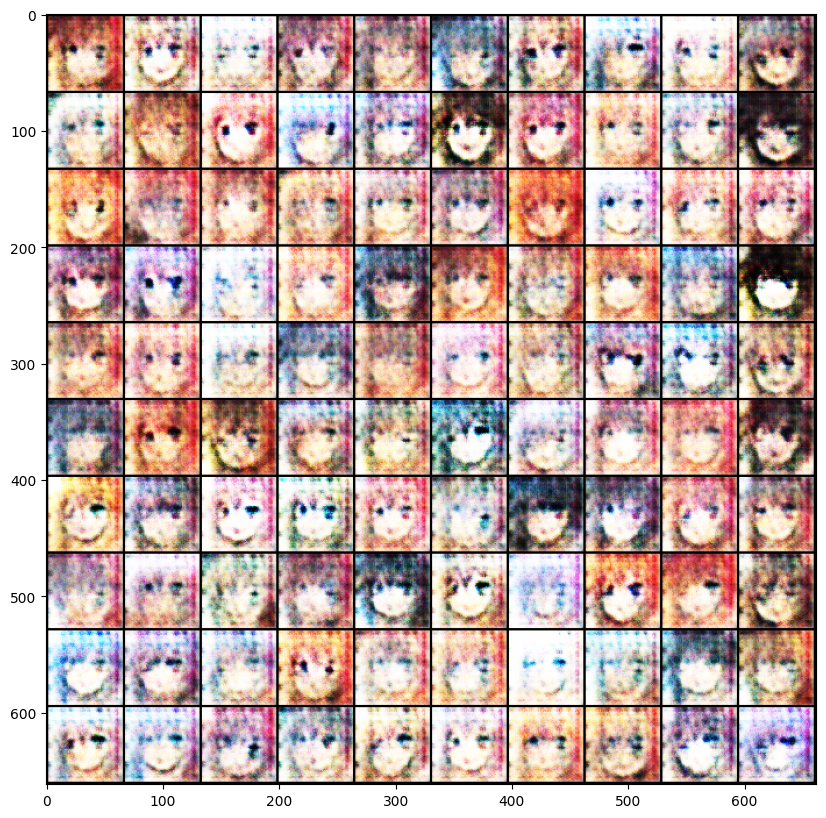

In [ ]:
steps = 0

for e in range(n_epoch):

    progress_bar = qqdm(dataloader)

    for i, data in enumerate(progress_bar):

        imgs = data.cuda()
        bs = imgs.size(0)

        # ======================================
        # Train Discriminator (SNGAN hinge loss)
        # ======================================

        z = torch.randn(bs, z_dim).cuda()
        fake_imgs = G(z).detach()

        real_out = D(imgs)
        fake_out = D(fake_imgs)

        loss_D = (
            torch.relu(1 - real_out).mean() +
            torch.relu(1 + fake_out).mean()
        )

        D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ======================================
        # Train Generator
        # ======================================

        z = torch.randn(bs, z_dim).cuda()
        fake_imgs = G(z)
        fake_out = D(fake_imgs)

        loss_G = -fake_out.mean()

        G.zero_grad()
        loss_G.backward()
        opt_G.step()

        # ======================================
        # Log
        # ======================================

        steps += 1

        progress_bar.set_infos({
            'Loss_D': round(loss_D.item(), 4),
            'Loss_G': round(loss_G.item(), 4),
            'Epoch': e + 1,
            'Step': steps,
        })

    # ======================================
    # Save samples
    # ======================================

    G.eval()
    with torch.no_grad():
        f_imgs_sample = (G(z_sample).cpu() + 1) / 2.0

    filename = os.path.join(log_dir, f'Epoch_{e+1:03d}.jpg')
    torchvision.utils.save_image(f_imgs_sample, filename, nrow=10)

    print(f' | Save samples to {filename}')

    grid_img = torchvision.utils.make_grid(f_imgs_sample, nrow=10)
    plt.figure(figsize=(10,10))
    plt.imshow(grid_img.permute(1,2,0))
    plt.show()

    G.train()

    # ======================================
    # Save checkpoint
    # ======================================

    if (e + 1) % 5 == 0 or e == 1:
        torch.save(G.state_dict(), os.path.join(ckpt_dir, 'G.pth'))
        torch.save(D.state_dict(), os.path.join(ckpt_dir, 'D.pth'))

## Inference
Use the trained model to generate anime faces!

### Load model

In [ ]:
if BASELINE == 'simple':
    print('Simple baseline: no trained generator to load.')
else:
    import torch

    G = Generator(z_dim)
    G.load_state_dict(torch.load(os.path.join(ckpt_dir, 'G.pth')))
    G.eval()
    G.cuda()


<ipython-input-20-3199515f434e>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  G.load_state_dict(torch.load(os.path.join(ckpt_dir, 'G.pth')))


Generator(
  (l1): Sequential(
    (0): Linear(in_features=100, out_features=8192, bias=False)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (l2_5): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()


### Generate and show some images.


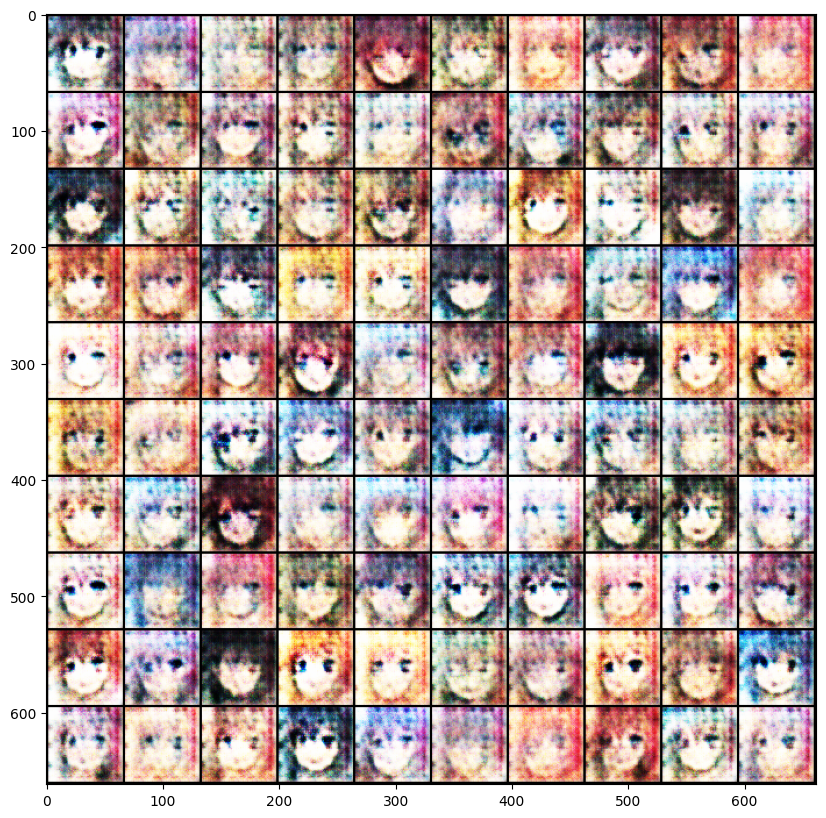

In [ ]:
# Generate 1000 images and make a grid to save them.
n_output = 1000
log_dir = os.path.join(workspace_dir, 'logs')
filename = os.path.join(log_dir, 'result.jpg')

if BASELINE == 'simple':
    # Random noise images in [0, 1], shape (N, 3, 64, 64)
    imgs_sample = torch.rand(n_output, 3, 64, 64)
else:
    z_sample = Variable(torch.randn(n_output, z_dim)).cuda()
    imgs_sample = (G(z_sample).data + 1) / 2.0

torchvision.utils.save_image(imgs_sample, filename, nrow=10)

# Show 100 of the images.
grid_img = torchvision.utils.make_grid(imgs_sample[:100].cpu(), nrow=10)
plt.figure(figsize=(10,10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.show()


### Compress the generated images using **tar**.


In [ ]:
if BASELINE != 'simple':
    # Save the generated images.
    os.makedirs('output', exist_ok=True)
    for i in range(1000):
        torchvision.utils.save_image(imgs_sample[i], f'output/{i+1}.jpg')

    # Compress the images.
    %cd output
    !tar -zcf ../images.tgz *.jpg
    %cd ..
else:
    print('Simple baseline: images are shown above; no tar archive required for submission.')


/content/output
/content
